In [1]:
%load_ext autoreload
%autoreload 2
import os
import sys
sys.path.append(os.path.abspath('..'))
import utils

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('Life-Expectancy-Data-Updated (1).csv')

In [7]:
#creamos la columna binaria correcta
df['Developed'] = (df['Economy_status_Developed'] == 1).astype(int)
df = df.drop(columns=['Economy_status_Developed'])
df = df.drop(columns=['Economy_status_Developing'])

La tasa de muertes infantiles de paises subdesarrollados del 2013 al 2014 se redujo significativamente.

Sabemos que los datos estan apareados, porque se toma el mismo grupo en dos instantes de tiempo diferentes. Asi, debemos usar un T-student de datos apareados, pero debemos comprobar la normalidad de las diferencias.

In [25]:
data_2013 = df[df['Year'] == 2013]
data_2014 = df[df['Year'] == 2014]

#separamos por grupos
paises_subdesarrollados_2013 = data_2013[data_2013['Developed'] == 0]

#separamos por grupos
paises_subdesarrollados_2014 = data_2014[data_2014['Developed'] == 0]

In [29]:
p13 = paises_subdesarrollados_2013[['Country', 'Infant_deaths']]
p14 = paises_subdesarrollados_2014[['Country', 'Infant_deaths']]

pareados = p13.merge(
    p14,
    on='Country',
    suffixes=('_2013', '_2014')
)

pareados['dif'] = (
    pareados['Infant_deaths_2014']
    - pareados['Infant_deaths_2013']
)
pareados

,Country,Infant_deaths_2013,Infant_deaths_2014,dif
0,Belize,14.6,13.9,-0.7
1,Grenada,13.8,14.0,0.2
2,Oman,9.7,9.7,0.0
3,Malaysia,6.8,6.8,0.0
4,Timor-Leste,45.9,44.3,-1.6
...,...,...,...,...
137,Sri Lanka,8.4,7.9,-0.5
138,Chad,78.9,77.3,-1.6
139,"Venezuela, RB",15.1,15.4,0.3
140,"Egypt, Arab Rep.",21.3,20.5,-0.8


<h3> Box-Plot

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

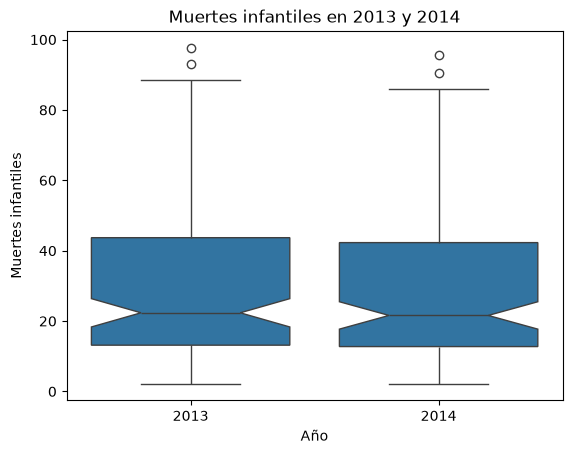

In [31]:
datos_box = pareados[['Infant_deaths_2013', 'Infant_deaths_2014']].melt(var_name='Year', value_name='Infant_deaths')
sns.boxplot(
    x='Year',
    y='Infant_deaths',
    data=datos_box,
    notch=True
)

plt.title("Muertes infantiles en 2013 y 2014")
plt.xlabel("Año")
plt.ylabel("Muertes infantiles")
plt.xticks(
    ticks=[0, 1],
    labels=["2013", "2014"]
)

plt.show()


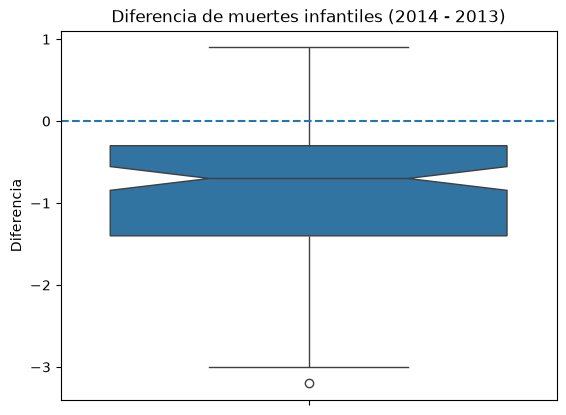

In [ ]:
sns.boxplot(y=pareados['dif'], notch=True)

plt.title("Diferencia de muertes infantiles (2014 - 2013)")
plt.ylabel("Diferencia")

plt.axhline(0, linestyle='--')

plt.show()

<h3>Normalidad

In [33]:
import scipy.stats as stats

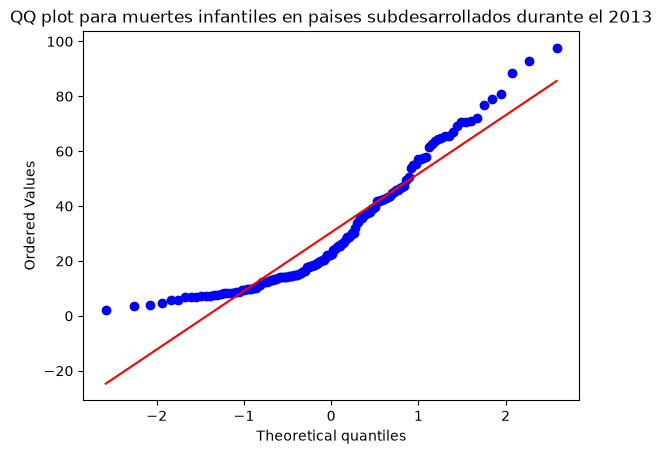

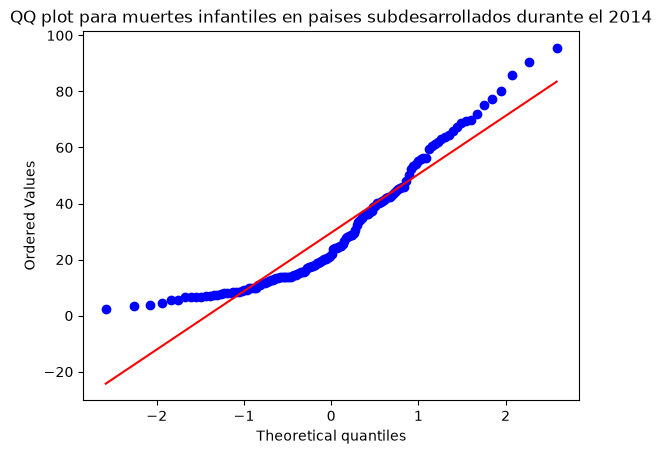

In [36]:
#QQ plot para paises desarrollados
stats.probplot(pareados['Infant_deaths_2013'], dist='norm', plot=plt)
plt.title('QQ plot para muertes infantiles en paises subdesarrollados durante el 2013')
plt.show()

stats.probplot(pareados['Infant_deaths_2014'], dist='norm', plot=plt)
plt.title('QQ plot para muertes infantiles en paises subdesarrollados durante el 2014')
plt.show()

In [41]:
from scipy.stats import shapiro

stat, p = shapiro(pareados['Infant_deaths_2013'])
print(f"Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para muertes infantibles durante 2013: Estadístico=0.899, p-valor=0.000


In [40]:
from scipy.stats import shapiro

stat, p = shapiro(pareados['Infant_deaths_2014'])
print(f"Test de Shapiro-Wilk para muertes infantibles durante 2014: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk para muertes infantibles durante 2014: Estadístico=0.898, p-valor=0.000


Vemos que ninguno de los dos sigue una distribucion normal, por lo que directamente nos vamos hacia la prueba Wilcoxon

In [44]:
resultado_w = stats.wilcoxon(pareados['Infant_deaths_2013'], pareados['Infant_deaths_2014'])

stat_w = float(resultado_w.statistic)
p_valor_w = float(resultado_w.pvalue)

print(f"Estadístico W: {stat_w:.4f}")
print(f"Valor p: {p_valor_w:.4f}")

if p_valor_w < 0.05:
    print("Rechazamos la hipótesis nula: Hay una diferencia significativa (Wilcoxon).")
else:
    print("No podemos rechazar la hipótesis nula: No hay diferencia significativa (Wilcoxon).")

Estadístico W: 456.5000
Valor p: 0.0000
Rechazamos la hipótesis nula: Hay una diferencia significativa (Wilcoxon).
